<a href="https://colab.research.google.com/github/Levi-003/AI-training-Tasks/blob/main/Student_Study_habits.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving UCI_Credit_Card.csv to UCI_Credit_Card.csv


In [ ]:
df = pd.read_csv("student_study_habits.csv")

print("Dataset loaded successfully!")

NameError: name 'pd' is not defined

In [ ]:
print(df.head())

   study_hours_per_week  sleep_hours_per_day  attendance_percentage  \
0              0.527230             0.685236               0.993245   
1              0.421400             0.881883               0.883478   
2              0.552393             0.220286               0.683469   
3              0.698283             0.612594               0.520094   
4              0.405419             0.369871               0.831127   

   assignments_completed  final_grade  participation_level_Low  \
0               0.222222    71.104897                      0.0   
1               0.555556    62.240021                      0.0   
2               1.000000    65.268855                      0.0   
3               0.222222    66.609921                      1.0   
4               0.333333    58.967484                      0.0   

   participation_level_Medium  internet_access_Yes  \
0                         1.0                  1.0   
1                         1.0                  1.0   
2             

In [ ]:
print(df.shape)

(500, 13)


In [ ]:
print(df.columns)

Index(['study_hours_per_week', 'sleep_hours_per_day', 'attendance_percentage',
       'assignments_completed', 'final_grade', 'participation_level_Low',
       'participation_level_Medium', 'internet_access_Yes',
       'parental_education_High School', 'parental_education_Master's',
       'parental_education_PhD', 'extracurricular_Yes', 'part_time_job_Yes'],
      dtype='object')


In [ ]:
print(df.isnull().sum())

study_hours_per_week              0
sleep_hours_per_day               0
attendance_percentage             0
assignments_completed             0
final_grade                       0
participation_level_Low           0
participation_level_Medium        0
internet_access_Yes               0
parental_education_High School    0
parental_education_Master's       0
parental_education_PhD            0
extracurricular_Yes               0
part_time_job_Yes                 0
dtype: int64


In [ ]:
import numpy as np

df["Performance"] = np.where(
    df["final_grade"] >= 50,
    "Pass",
    "Fail"
)

In [ ]:
X = df[
    [
        "study_hours_per_week",
        "attendance_percentage",
        "assignments_completed",
        "sleep_hours_per_day",
        "parental_education_High School",
        "parental_education_Master's",
        "parental_education_PhD"
    ]
]

y = df["Performance"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy * 100, "%")

Random Forest Accuracy: 97.0 %


In [ ]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()

nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

nb_accuracy = accuracy_score(y_test, nb_pred)

print("Naive Bayes Accuracy:", nb_accuracy * 100, "%")

Naive Bayes Accuracy: 31.0 %


In [ ]:
student = pd.DataFrame({
    "study_hours_per_week": [15],
    "attendance_percentage": [90],
    "assignments_completed": [10],
    "sleep_hours_per_day": [8],
    "parental_education_High School": [0],
    "parental_education_Master's": [0],
    "parental_education_PhD": [0]
})

In [ ]:
print("Random Forest:",
      rf_model.predict(student)[0])

print("Naive Bayes:",
      nb_model.predict(student)[0])

Random Forest: Pass
Naive Bayes: Fail


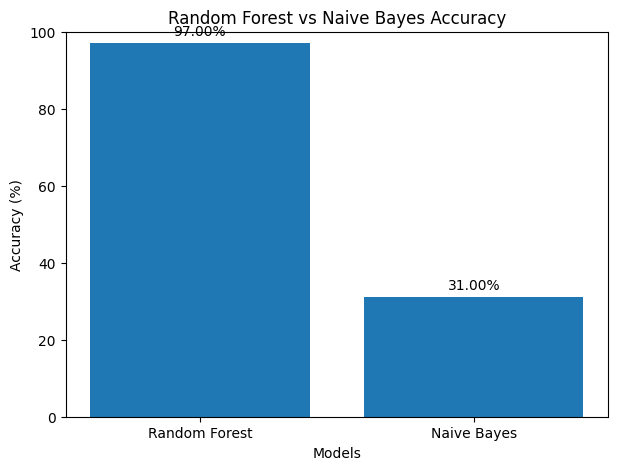

In [ ]:
import matplotlib.pyplot as plt

models = ["Random Forest", "Naive Bayes"]
accuracies = [rf_accuracy * 100, nb_accuracy * 100]

plt.figure(figsize=(7, 5))

plt.bar(models, accuracies)

plt.xlabel("Models")
plt.ylabel("Accuracy (%)")
plt.title("Random Forest vs Naive Bayes Accuracy")

plt.ylim(0, 100)

for i, value in enumerate(accuracies):
    plt.text(i, value + 2, f"{value:.2f}%", ha="center")

plt.show()